In [17]:
!pip install -q datasets soundfile librosa transformers
!pip install -q matplotlib seaborn pandas numpy jiwer evaluate
!pip install -q huggingface_hub

In [18]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('EDA_TOKEN'))
print("✅ Authenticated with HuggingFace")

# ── USER CONFIGURATION — edit these to match your dataset ───
DATASET_NAME   = "Anv-ke/kikuyu"  # ← CHANGE THIS
AUDIO_COL      = "audio"          # column containing audio
TRANSCRIPT_COL = "transcription"  # column containing text
SPEAKER_COL    = "speaker_id"     # set to None if not present
LANGUAGE_COL   = "language"       # set to None if not present
DOMAIN_COL     = "domain"         # set to None if not present
SAMPLE_SIZE    = 1000             # examples to analyse per section
                                  # increase for deeper analysis

✅ Authenticated with HuggingFace


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Audio
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("✅ Libraries loaded")

✅ Libraries loaded


In [20]:
print(f"Streaming first {SAMPLE_SIZE} examples from '{DATASET_NAME}'...")

import librosa
from google.colab import userdata # Import userdata here to get the token directly

stream = load_dataset(
    DATASET_NAME, split="train",
    streaming=True,
    token=userdata.get('EDA_TOKEN') # Pass the token explicitly
)
stream = stream.cast_column(AUDIO_COL, Audio(sampling_rate=16000))

records = []
for i, ex in enumerate(stream):
    if i >= SAMPLE_SIZE:
        break

    transcript = str(ex.get(TRANSCRIPT_COL, "")).strip()
    audio_obj  = ex[AUDIO_COL] # Get the AudioDecoder object directly
    arr        = np.array(audio_obj['array'], dtype=np.float32) # Access via dictionary-like key
    sr         = audio_obj['sampling_rate'] # Access via dictionary-like key

    # ── Audio features ──────────────────────────────────────
    duration       = len(arr) / sr if sr > 0 else 0
    rms            = float(np.sqrt(np.mean(arr**2))) if len(arr) > 0 else 0
    peak           = float(np.max(np.abs(arr))) if len(arr) > 0 else 0
    silence_ratio  = float(np.mean(np.abs(arr) < 0.005)) if len(arr) > 0 else 1.0
    is_clipped     = peak >= 0.99
    snr_proxy      = float(rms / (np.std(arr[arr < np.percentile(arr, 10)]) + 1e-9)) if len(arr) > 5 else 0

    # ── Text features ────────────────────────────────────────
    words          = transcript.split()
    word_count     = len(words)
    char_count     = len(transcript)
    has_url        = bool(re.search(r'https?://', transcript))
    has_newline    = '\n' in transcript or '\n' in transcript
    has_underscore = '_' in transcript
    unique_chars   = set(transcript.lower())

    # Words per second (alignment proxy)
    wps = word_count / duration if duration > 0 else 0

    rec = {
        # audio
        "duration_sec":    duration,
        "rms":             rms,
        "peak":            peak,
        "silence_ratio":   silence_ratio,
        "is_clipped":      is_clipped,
        "snr_proxy":       snr_proxy,
        "sampling_rate":   sr,
        # text
        "transcript":      transcript,
        "word_count":      word_count,
        "char_count":      char_count,
        "has_url":         has_url,
        "has_newline":     has_newline,
        "has_underscore":  has_underscore,
        "unique_chars":    unique_chars,
        "wps":             wps,
    }

    # Optional columns
    if SPEAKER_COL and SPEAKER_COL in ex:
        rec["speaker_id"] = ex[SPEAKER_COL]
    if LANGUAGE_COL and LANGUAGE_COL in ex:
        rec["language"] = ex[LANGUAGE_COL]
    if DOMAIN_COL and DOMAIN_COL in ex:
        rec["domain"] = ex[DOMAIN_COL]

    records.append(rec)

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{SAMPLE_SIZE}...")

df = pd.DataFrame(records)
print(f"\n✅ Collected {len(df)} samples. Ready for EDA.")

Streaming first 1000 examples from 'Anv-ke/kikuyu'...


Resolving data files:   0%|          | 0/261 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

  Processed 100/1000...
  Processed 200/1000...
  Processed 300/1000...
  Processed 400/1000...
  Processed 500/1000...
  Processed 600/1000...
  Processed 700/1000...
  Processed 800/1000...
  Processed 900/1000...
  Processed 1000/1000...

✅ Collected 1000 samples. Ready for EDA.



SECTION 1: DATA VOLUME & COVERAGE
  Samples analysed:        1,000
  Total audio duration:    1.81 hours
  Mean utterance length:   6.50 seconds
  Total words (sample):    12,800
  Mean words/utterance:    12.8


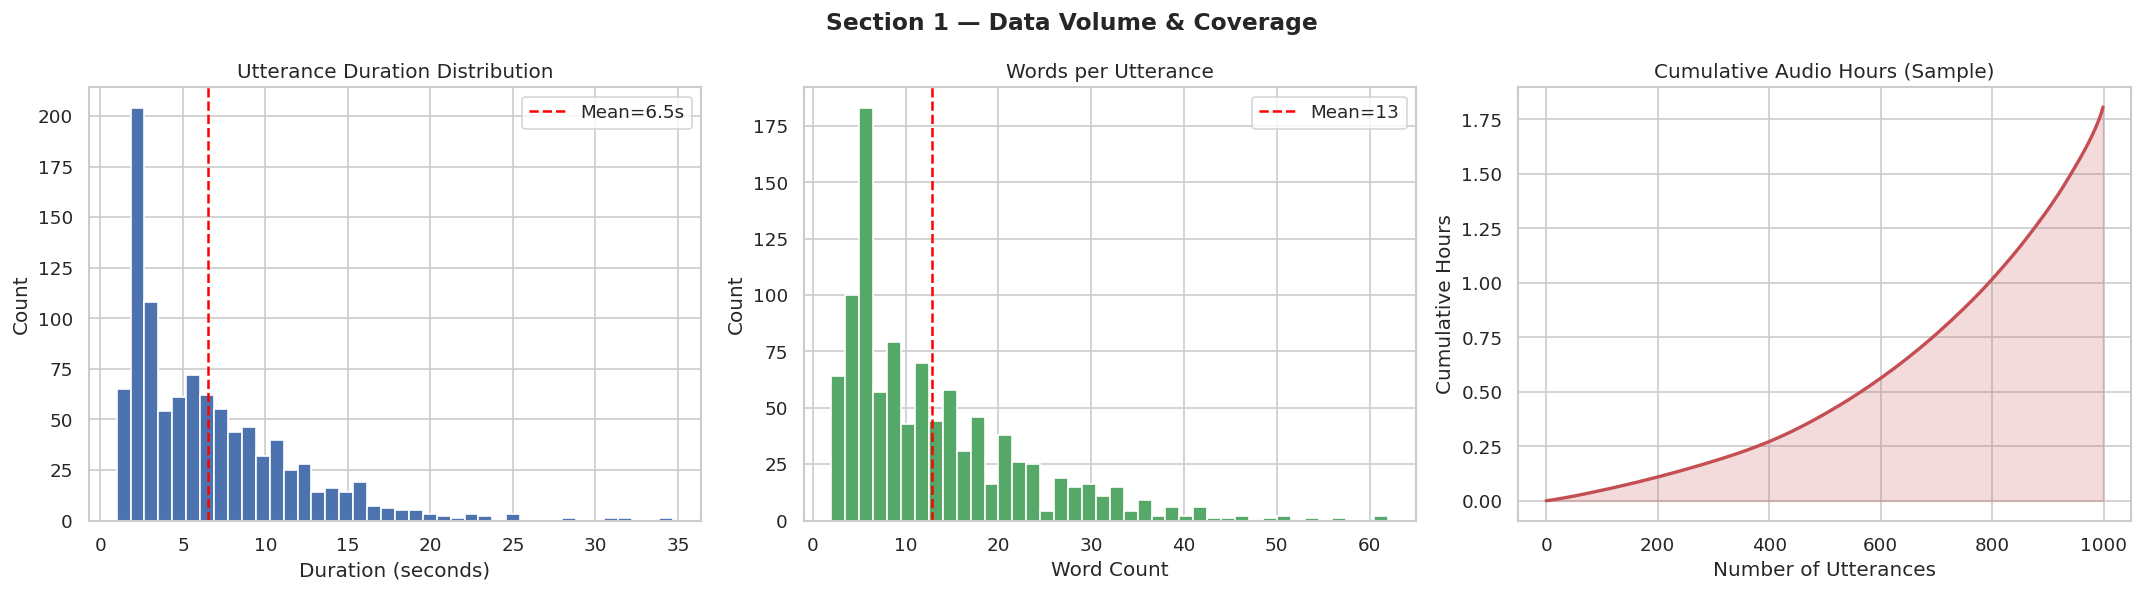

✅ Saved: eda_section1_volume.png


In [21]:
print("\n" + "="*60)
print("SECTION 1: DATA VOLUME & COVERAGE")
print("="*60)

total_dur_hrs  = df["duration_sec"].sum() / 3600
mean_dur       = df["duration_sec"].mean()
total_words    = df["word_count"].sum()

print(f"  Samples analysed:        {len(df):,}")
print(f"  Total audio duration:    {total_dur_hrs:.2f} hours")
print(f"  Mean utterance length:   {mean_dur:.2f} seconds")
print(f"  Total words (sample):    {total_words:,}")
print(f"  Mean words/utterance:    {df['word_count'].mean():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 1 — Data Volume & Coverage", fontsize=14, fontweight="bold")

# Duration distribution
axes[0].hist(df["duration_sec"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(mean_dur, color="red", linestyle="--", label=f"Mean={mean_dur:.1f}s")
axes[0].set_title("Utterance Duration Distribution")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Word count distribution
axes[1].hist(df["word_count"], bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(df["word_count"].mean(), color="red", linestyle="--",
                label=f"Mean={df['word_count'].mean():.0f}")
axes[1].set_title("Words per Utterance")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Count")
axes[1].legend()

# Cumulative audio hours
sorted_dur = np.sort(df["duration_sec"].values)
cumulative = np.cumsum(sorted_dur) / 3600
axes[2].plot(cumulative, color="#C44E52", linewidth=2)
axes[2].set_title("Cumulative Audio Hours (Sample)")
axes[2].set_xlabel("Number of Utterances")
axes[2].set_ylabel("Cumulative Hours")
axes[2].fill_between(range(len(cumulative)), cumulative, alpha=0.2, color="#C44E52")

plt.tight_layout()
plt.savefig("eda_section1_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section1_volume.png")


SECTION 2: AUDIO QUALITY ANALYSIS
  Clipped audio:           0 (0.0%)
  High silence (>50%):     28 files
  Very short (<1s):        1 files
  Very long (>30s):        3 files
  Very quiet (low RMS):    2 files
  Mean RMS loudness:       0.0708
  Mean silence ratio:      30.37%


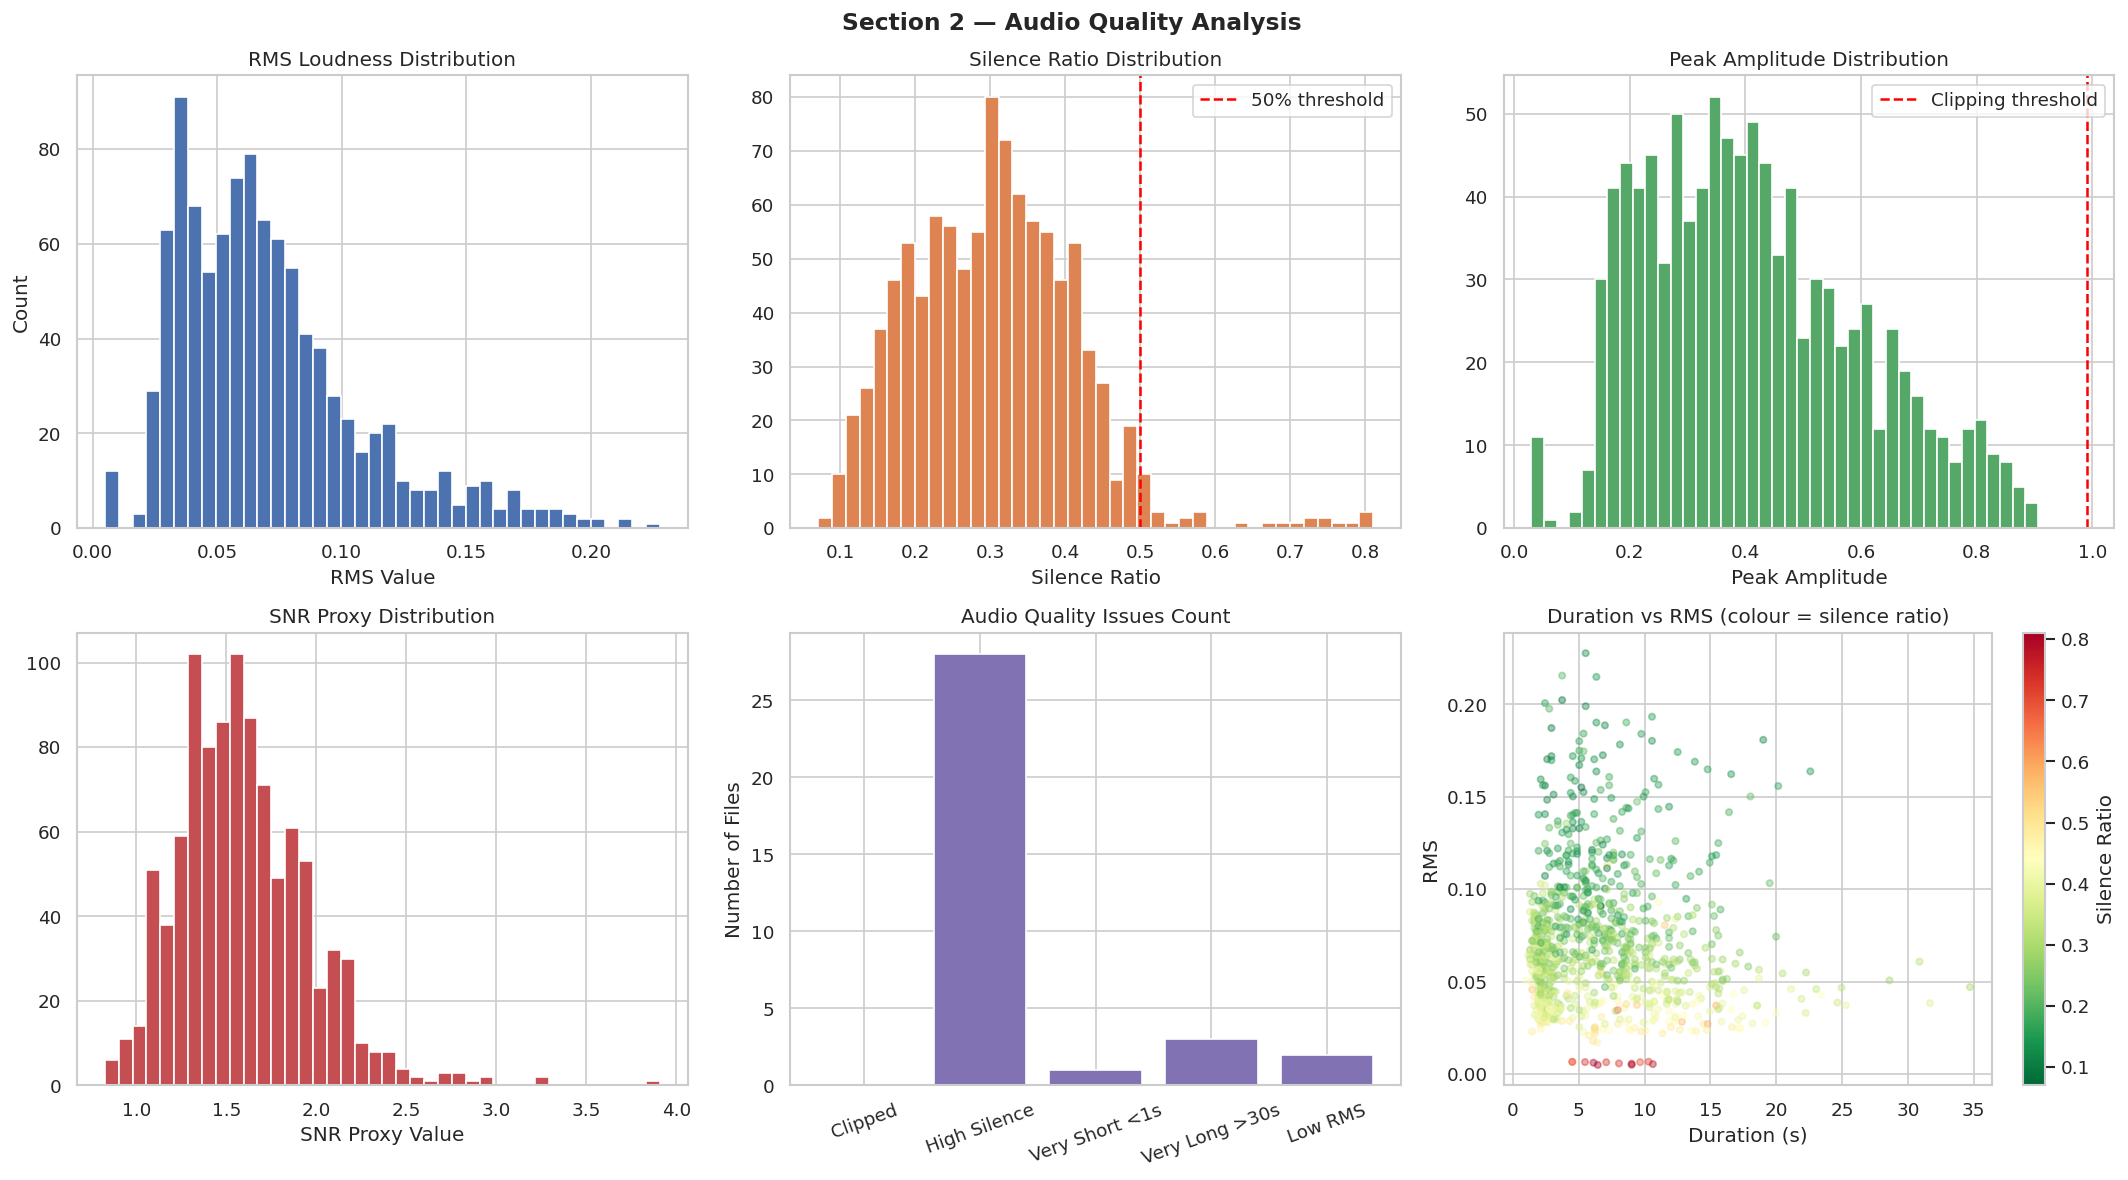

✅ Saved: eda_section2_audio_quality.png


In [22]:
print("\n" + "="*60)
print("SECTION 2: AUDIO QUALITY ANALYSIS")
print("="*60)

clipped_pct  = df["is_clipped"].mean() * 100
high_silence = (df["silence_ratio"] > 0.5).sum()
very_short   = (df["duration_sec"] < 1).sum()
very_long    = (df["duration_sec"] > 30).sum()
low_rms      = (df["rms"] < 0.005).sum()

print(f"  Clipped audio:           {df['is_clipped'].sum()} ({clipped_pct:.1f}%)")
print(f"  High silence (>50%):     {high_silence} files")
print(f"  Very short (<1s):        {very_short} files")
print(f"  Very long (>30s):        {very_long} files")
print(f"  Very quiet (low RMS):    {low_rms} files")
print(f"  Mean RMS loudness:       {df['rms'].mean():.4f}")
print(f"  Mean silence ratio:      {df['silence_ratio'].mean():.2%}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section 2 — Audio Quality Analysis", fontsize=14, fontweight="bold")

# RMS loudness
axes[0,0].hist(df["rms"], bins=40, color="#4C72B0", edgecolor="white")
axes[0,0].set_title("RMS Loudness Distribution")
axes[0,0].set_xlabel("RMS Value")
axes[0,0].set_ylabel("Count")

# Silence ratio
axes[0,1].hist(df["silence_ratio"], bins=40, color="#DD8452", edgecolor="white")
axes[0,1].axvline(0.5, color="red", linestyle="--", label="50% threshold")
axes[0,1].set_title("Silence Ratio Distribution")
axes[0,1].set_xlabel("Silence Ratio")
axes[0,1].legend()

# Peak amplitude
axes[0,2].hist(df["peak"], bins=40, color="#55A868", edgecolor="white")
axes[0,2].axvline(0.99, color="red", linestyle="--", label="Clipping threshold")
axes[0,2].set_title("Peak Amplitude Distribution")
axes[0,2].set_xlabel("Peak Amplitude")
axes[0,2].legend()

# SNR proxy
axes[1,0].hist(df["snr_proxy"].clip(0, 100), bins=40, color="#C44E52", edgecolor="white")
axes[1,0].set_title("SNR Proxy Distribution")
axes[1,0].set_xlabel("SNR Proxy Value")

# Quality flags bar chart
flags = {
    "Clipped":        df["is_clipped"].sum(),
    "High Silence":   high_silence,
    "Very Short <1s": very_short,
    "Very Long >30s": very_long,
    "Low RMS":        low_rms,
}
axes[1,1].bar(flags.keys(), flags.values(), color="#8172B3", edgecolor="white")
axes[1,1].set_title("Audio Quality Issues Count")
axes[1,1].set_ylabel("Number of Files")
axes[1,1].tick_params(axis="x", rotation=20)

# Duration vs RMS scatter
axes[1,2].scatter(df["duration_sec"], df["rms"], alpha=0.4,
                  c=df["silence_ratio"], cmap="RdYlGn_r", s=15)
axes[1,2].set_title("Duration vs RMS (colour = silence ratio)")
axes[1,2].set_xlabel("Duration (s)")
axes[1,2].set_ylabel("RMS")
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r",
     norm=plt.Normalize(df["silence_ratio"].min(), df["silence_ratio"].max()))
plt.colorbar(sm, ax=axes[1,2], label="Silence Ratio")

plt.tight_layout()
plt.savefig("eda_section2_audio_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section2_audio_quality.png")


SECTION 3: TRANSCRIPT QUALITY & LINGUISTIC ANALYSIS
  Empty transcriptions:    0
  Contains URLs:           0 (0.0%)
  Contains newlines:       0 (0.0%)
  Contains underscores:    0 (0.0%)

  Diacritic variants found:
    'i' variants: {'i': 5835, 'ĩ': 5065, 'ì': 12, 'ï': 2}
    'u' variants: {'ũ': 4114, 'u': 1803, 'ū': 8, 'û': 1, 'ú': 2}


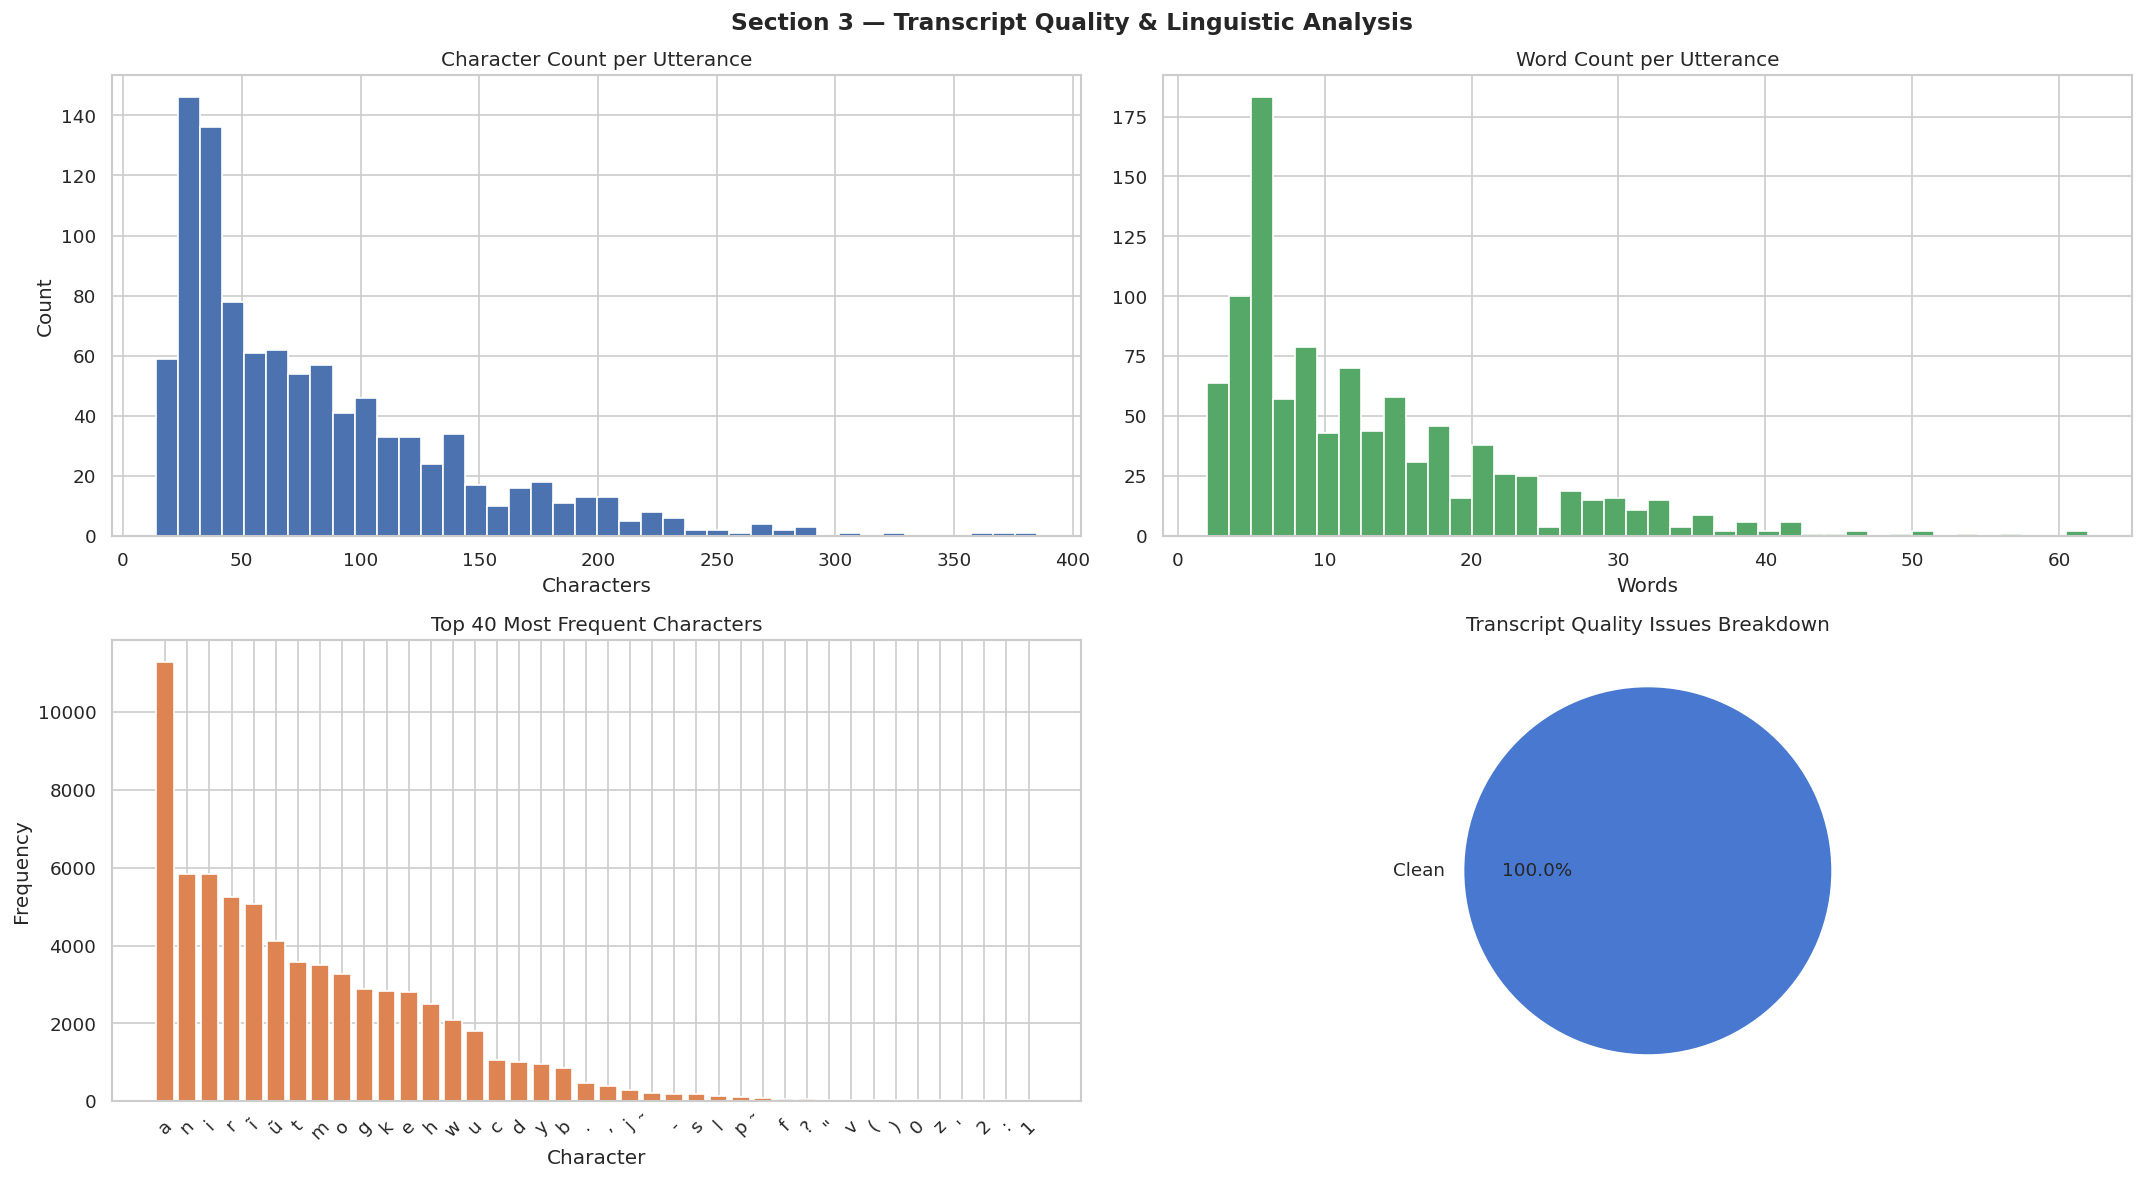

✅ Saved: eda_section3_transcript_quality.png


In [23]:
print("\n" + "="*60)
print("SECTION 3: TRANSCRIPT QUALITY & LINGUISTIC ANALYSIS")
print("="*60)

has_url_pct  = df["has_url"].mean() * 100
has_nl_pct   = df["has_newline"].mean() * 100
has_us_pct   = df["has_underscore"].mean() * 100
empty        = (df["word_count"] == 0).sum()

print(f"  Empty transcriptions:    {empty}")
print(f"  Contains URLs:           {df['has_url'].sum()} ({has_url_pct:.1f}%)")
print(f"  Contains newlines:       {df['has_newline'].sum()} ({has_nl_pct:.1f}%)")
print(f"  Contains underscores:    {df['has_underscore'].sum()} ({has_us_pct:.1f}%)")

# Character frequency
all_text  = " ".join(df["transcript"].tolist()).lower()
char_freq = Counter(c for c in all_text if c.strip())
top_chars = pd.DataFrame(char_freq.most_common(40), columns=["char", "count"])

# Diacritic variants
diacritic_variants = {
    "i": Counter(re.findall(r'[iìíîïīĩ]', all_text)),
    "u": Counter(re.findall(r'[uùúûüūũ]', all_text)),
    "a": Counter(re.findall(r'[aàáâäāã]', all_text)),
}

print("\n  Diacritic variants found:")
for vowel, counts in diacritic_variants.items():
    if len(counts) > 1:
        print(f"    '{vowel}' variants: {dict(counts)}")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Section 3 — Transcript Quality & Linguistic Analysis",
             fontsize=14, fontweight="bold")

# Character count distribution
axes[0,0].hist(df["char_count"], bins=40, color="#4C72B0", edgecolor="white")
axes[0,0].set_title("Character Count per Utterance")
axes[0,0].set_xlabel("Characters")
axes[0,0].set_ylabel("Count")

# Word count distribution
axes[0,1].hist(df["word_count"], bins=40, color="#55A868", edgecolor="white")
axes[0,1].set_title("Word Count per Utterance")
axes[0,1].set_xlabel("Words")

# Top 40 characters
axes[1,0].bar(top_chars["char"], top_chars["count"], color="#DD8452")
axes[1,0].set_title("Top 40 Most Frequent Characters")
axes[1,0].set_xlabel("Character")
axes[1,0].set_ylabel("Frequency")
axes[1,0].tick_params(axis="x", rotation=45)

# Quality issues pie
issues = {
    "Has URL":        df["has_url"].sum(),
    "Has Newline":    df["has_newline"].sum(),
    "Has Underscore": df["has_underscore"].sum(),
    "Clean":          len(df) - df["has_url"].sum() - df["has_newline"].sum() - df["has_underscore"].sum(),
}
clean_issues = {k: v for k, v in issues.items() if v > 0}
axes[1,1].pie(clean_issues.values(), labels=clean_issues.keys(),
              autopct="%1.1f%%", colors=sns.color_palette("muted", len(clean_issues)))
axes[1,1].set_title("Transcript Quality Issues Breakdown")

plt.tight_layout()
plt.savefig("eda_section3_transcript_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section3_transcript_quality.png")

In [24]:
print("\n" + "="*60)
print("SECTION 4: SPEAKER DIVERSITY")
print("="*60)

if "speaker_id" not in df.columns:
    print("⚠️  No speaker_id column found in this dataset.")
    print("   Speaker diversity analysis requires a speaker_id column.")
    print("   Skipping this section.")
else:
    speaker_counts = df["speaker_id"].value_counts()
    n_speakers     = df["speaker_id"].nunique()
    top_speaker_pct = speaker_counts.iloc[0] / len(df) * 100

    print(f"  Unique speakers:         {n_speakers}")
    print(f"  Utterances per speaker:")
    print(f"    Min:  {speaker_counts.min()}")
    print(f"    Max:  {speaker_counts.max()}")
    print(f"    Mean: {speaker_counts.mean():.1f}")
    print(f"  Most dominant speaker:   {top_speaker_pct:.1f}% of sample")

    # Per-speaker audio duration
    df["duration_sec_copy"] = df["duration_sec"]
    speaker_duration = df.groupby("speaker_id")["duration_sec_copy"].sum().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Section 4 — Speaker Diversity", fontsize=14, fontweight="bold")

    # Utterances per speaker (top 30)
    top30 = speaker_counts.head(30)
    axes[0].bar(range(len(top30)), top30.values, color="#4C72B0")
    axes[0].set_title("Utterances per Speaker (Top 30)")
    axes[0].set_xlabel("Speaker Rank")
    axes[0].set_ylabel("Utterance Count")

    # Distribution of utterances per speaker
    axes[1].hist(speaker_counts.values, bins=30, color="#55A868", edgecolor="white")
    axes[1].set_title("Distribution of Utterances per Speaker")
    axes[1].set_xlabel("Utterances")
    axes[1].set_ylabel("Number of Speakers")

    # Audio hours per speaker (top 20)
    top20_dur = speaker_duration.head(20)
    axes[2].barh(range(len(top20_dur)), top20_dur.values / 3600, color="#C44E52")
    axes[2].set_yticks(range(len(top20_dur)))
    axes[2].set_yticklabels(top20_dur.index, fontsize=8)
    axes[2].set_title("Audio Hours per Speaker (Top 20)")
    axes[2].set_xlabel("Hours")

    plt.tight_layout()
    plt.savefig("eda_section4_speaker_diversity.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: eda_section4_speaker_diversity.png")



SECTION 4: SPEAKER DIVERSITY
⚠️  No speaker_id column found in this dataset.
   Speaker diversity analysis requires a speaker_id column.
   Skipping this section.



SECTION 5: UTTERANCE-LEVEL STATISTICS
  Word count stats:
count    1000.00
mean       12.80
std         9.67
min         2.00
25%         5.00
50%        10.00
75%        17.00
max        62.00

  Duration stats (seconds):
count    1000.00
mean        6.50
std         4.84
min         0.98
25%         2.60
50%         5.20
75%         8.94
max        34.72

  Characters per word:
count    1000.00
mean        6.53
std         1.01
min         3.80
25%         5.89
50%         6.33
75%         7.00
max        12.00


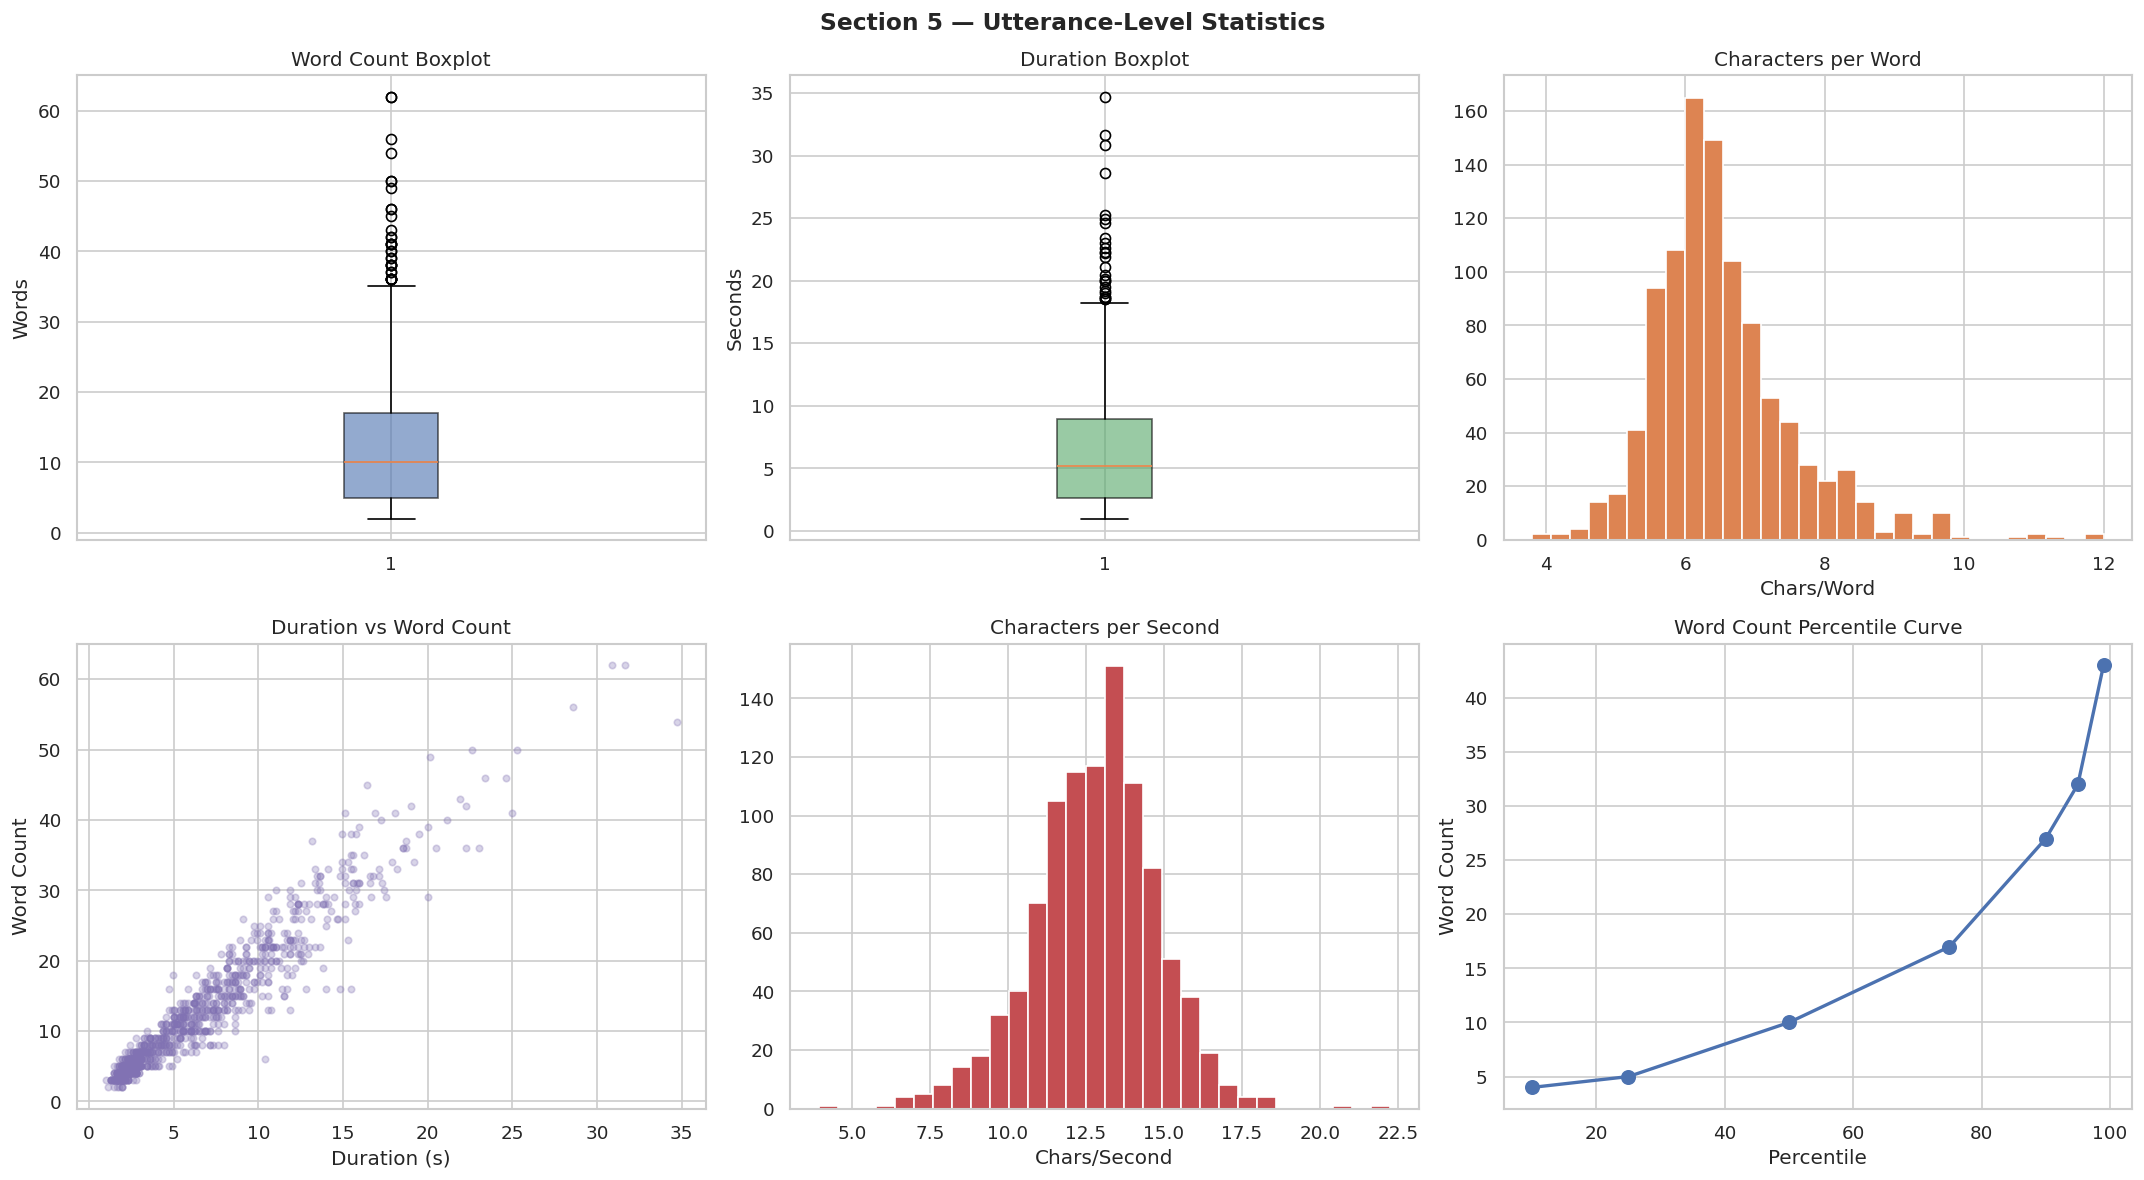

✅ Saved: eda_section5_utterance_stats.png


In [25]:
print("\n" + "="*60)
print("SECTION 5: UTTERANCE-LEVEL STATISTICS")
print("="*60)

df["chars_per_word"] = df["char_count"] / df["word_count"].replace(0, np.nan)
df["chars_per_sec"]  = df["char_count"] / df["duration_sec"].replace(0, np.nan)

print("  Word count stats:")
print(df["word_count"].describe().round(2).to_string())
print("\n  Duration stats (seconds):")
print(df["duration_sec"].describe().round(2).to_string())
print("\n  Characters per word:")
print(df["chars_per_word"].describe().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section 5 — Utterance-Level Statistics",
             fontsize=14, fontweight="bold")

# Word count boxplot
axes[0,0].boxplot(df["word_count"].dropna(), vert=True, patch_artist=True,
                  boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[0,0].set_title("Word Count Boxplot")
axes[0,0].set_ylabel("Words")

# Duration boxplot
axes[0,1].boxplot(df["duration_sec"].dropna(), vert=True, patch_artist=True,
                  boxprops=dict(facecolor="#55A868", alpha=0.6))
axes[0,1].set_title("Duration Boxplot")
axes[0,1].set_ylabel("Seconds")

# Chars per word
axes[0,2].hist(df["chars_per_word"].dropna(), bins=30, color="#DD8452", edgecolor="white")
axes[0,2].set_title("Characters per Word")
axes[0,2].set_xlabel("Chars/Word")

# Duration vs word count scatter
axes[1,0].scatter(df["duration_sec"], df["word_count"], alpha=0.3, s=15, color="#8172B3")
axes[1,0].set_title("Duration vs Word Count")
axes[1,0].set_xlabel("Duration (s)")
axes[1,0].set_ylabel("Word Count")

# Chars per second
axes[1,1].hist(df["chars_per_sec"].dropna().clip(0, 50), bins=30,
               color="#C44E52", edgecolor="white")
axes[1,1].set_title("Characters per Second")
axes[1,1].set_xlabel("Chars/Second")

# Word count percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
pct_values  = [np.percentile(df["word_count"], p) for p in percentiles]
axes[1,2].plot(percentiles, pct_values, "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[1,2].set_title("Word Count Percentile Curve")
axes[1,2].set_xlabel("Percentile")
axes[1,2].set_ylabel("Word Count")
axes[1,2].grid(True)

plt.tight_layout()
plt.savefig("eda_section5_utterance_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section5_utterance_stats.png")



SECTION 6: TEXT-AUDIO ALIGNMENT INTEGRITY
  Normal alignment (0.5–5 wps):  1000 (100.0%)
  Suspiciously fast (>5 wps):    0 (0.0%)
  Suspiciously slow (<0.5 wps):  0 (0.0%)

  Words-per-second stats:
count    1000.000
mean        1.999
std         0.398
min         0.577
25%         1.735
50%         2.010
75%         2.267
max         3.630


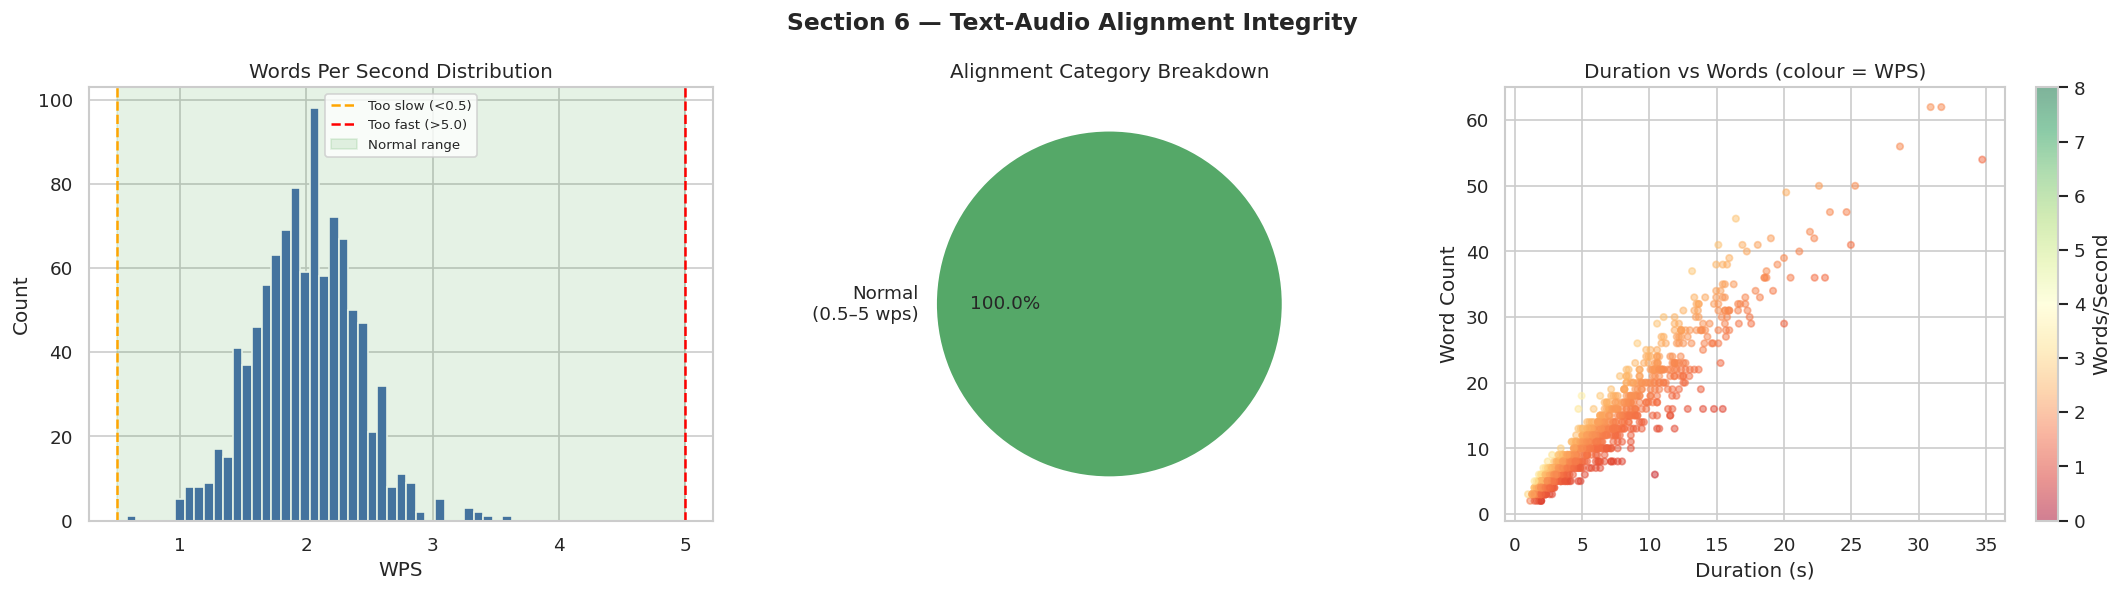

✅ Saved: eda_section6_alignment.png


In [26]:
print("\n" + "="*60)
print("SECTION 6: TEXT-AUDIO ALIGNMENT INTEGRITY")
print("="*60)

# Words per second is the key alignment proxy
# Normal speech is roughly 2–4 words per second
# Too fast → transcript is longer than audio (mismatch)
# Too slow → audio is longer than transcript (mismatch or silence)

df["wps"] = df["word_count"] / df["duration_sec"].replace(0, np.nan)

too_fast  = (df["wps"] > 5).sum()   # >5 wps = suspiciously fast
too_slow  = (df["wps"] < 0.5).sum() # <0.5 wps = suspiciously slow
normal    = ((df["wps"] >= 0.5) & (df["wps"] <= 5)).sum()

print(f"  Normal alignment (0.5–5 wps):  {normal} ({normal/len(df)*100:.1f}%)")
print(f"  Suspiciously fast (>5 wps):    {too_fast} ({too_fast/len(df)*100:.1f}%)")
print(f"  Suspiciously slow (<0.5 wps):  {too_slow} ({too_slow/len(df)*100:.1f}%)")
print(f"\n  Words-per-second stats:")
print(df["wps"].describe().round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 6 — Text-Audio Alignment Integrity",
             fontsize=14, fontweight="bold")

# WPS distribution
axes[0].hist(df["wps"].clip(0, 10), bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(0.5, color="orange", linestyle="--", label="Too slow (<0.5)")
axes[0].axvline(5.0, color="red",    linestyle="--", label="Too fast (>5.0)")
axes[0].axvspan(0.5, 5.0, alpha=0.1, color="green", label="Normal range")
axes[0].set_title("Words Per Second Distribution")
axes[0].set_xlabel("WPS")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# Alignment categories pie
cats   = {"Normal\n(0.5–5 wps)": normal, "Too Fast\n(>5 wps)": too_fast,
          "Too Slow\n(<0.5 wps)": too_slow}
colors = ["#55A868", "#C44E52", "#DD8452"]
axes[1].pie([v for v in cats.values() if v > 0],
            labels=[k for k, v in cats.items() if v > 0],
            autopct="%1.1f%%", colors=colors[:sum(v > 0 for v in cats.values())])
axes[1].set_title("Alignment Category Breakdown")

# Scatter: duration vs word count with WPS colour
sc = axes[2].scatter(df["duration_sec"], df["word_count"],
                     c=df["wps"].clip(0, 8), cmap="RdYlGn",
                     vmin=0, vmax=8, alpha=0.5, s=15)
plt.colorbar(sc, ax=axes[2], label="Words/Second")
axes[2].set_title("Duration vs Words (colour = WPS)")
axes[2].set_xlabel("Duration (s)")
axes[2].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig("eda_section6_alignment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section6_alignment.png")


SECTION 7: PHONEME & GRAPHEME COVERAGE
  Unique graphemes found:   45
  Total character tokens:   67,843

  Kikuyu vowel+diacritic usage:
    Plain i: 5,835 (8.60%)
    ì (grave): 12 (0.02%)
    ĩ (tilde): 5,065 (7.47%)
    Plain u: 1,803 (2.66%)
    ū (macron): 8 (0.01%)
    ù (grave): 0 (0.00%)
    ũ (tilde): 4,114 (6.06%)


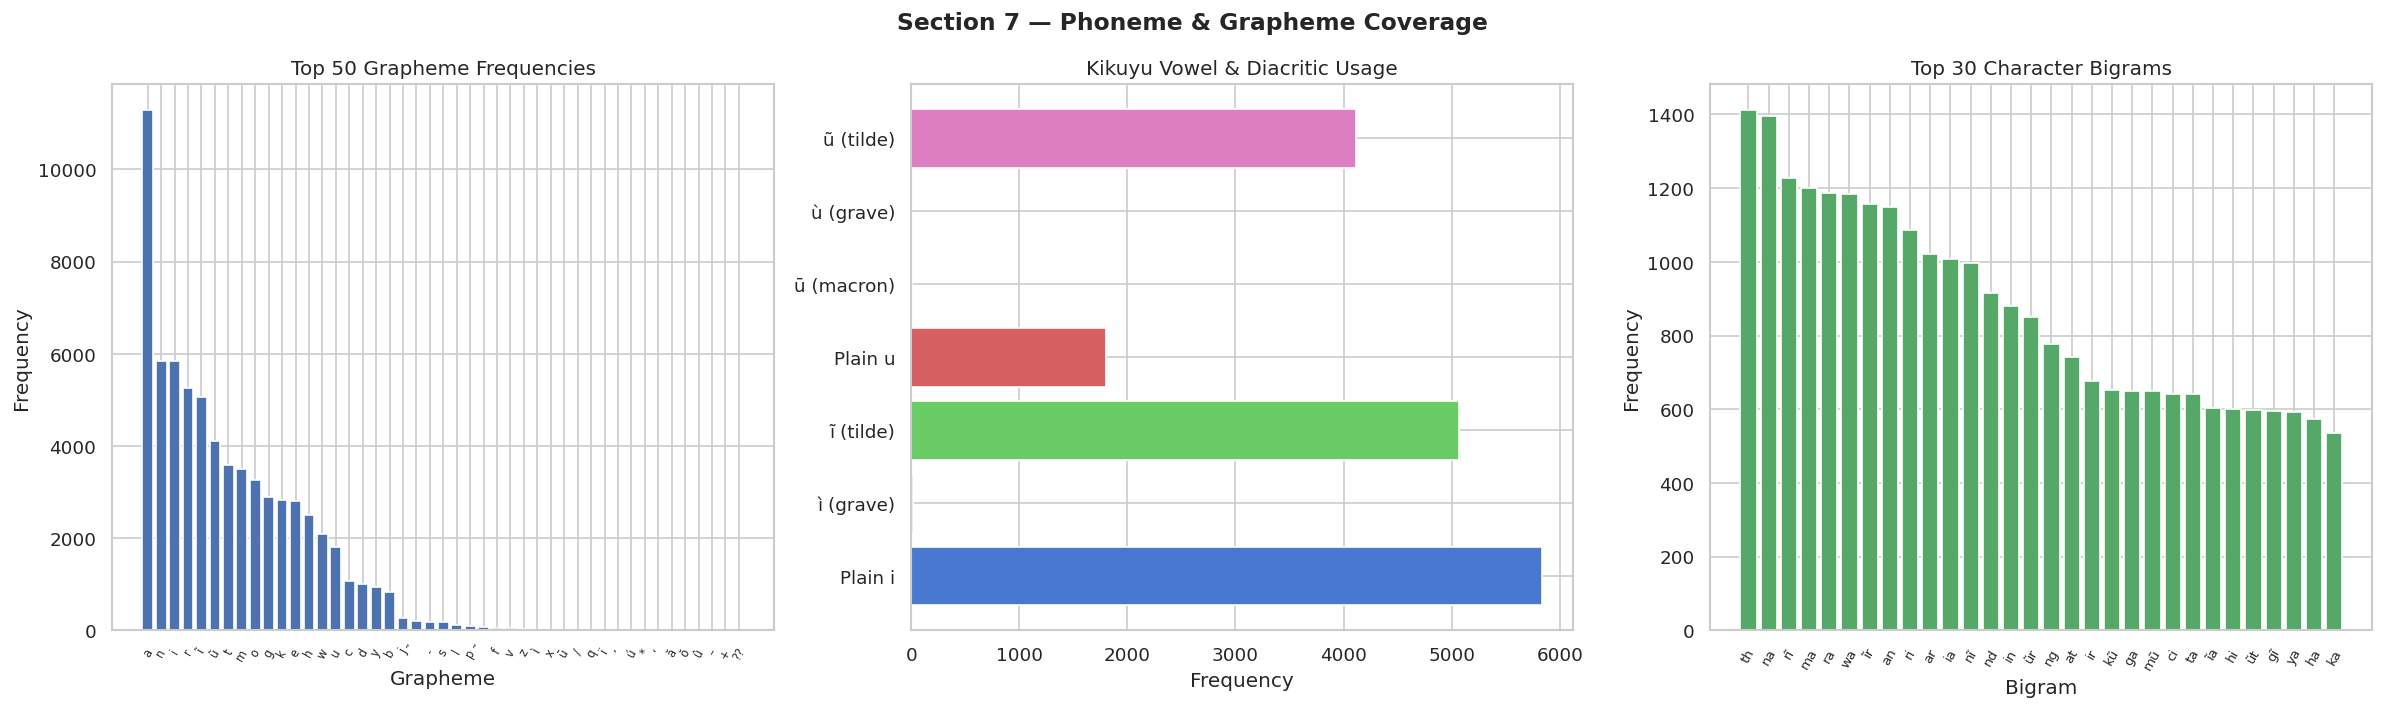

✅ Saved: eda_section7_grapheme_coverage.png


In [27]:
print("\n" + "="*60)
print("SECTION 7: PHONEME & GRAPHEME COVERAGE")
print("="*60)

all_text = " ".join(df["transcript"].tolist()).lower()

# Grapheme (character) inventory
graphemes = Counter(c for c in all_text if c.strip() and c not in ".,!?;:\"'()[]{}0123456789")
total_chars = sum(graphemes.values())

# Unique grapheme count
print(f"  Unique graphemes found:   {len(graphemes)}")
print(f"  Total character tokens:   {total_chars:,}")

# Kikuyu vowels with diacritics
kikuyu_vowels = {
    "Plain i":    all_text.count("i"),
    "ì (grave)":  all_text.count("ì"),
    "ĩ (tilde)":  all_text.count("ĩ"),
    "Plain u":    all_text.count("u"),
    "ū (macron)": all_text.count("ū"),
    "ù (grave)":  all_text.count("ù"),
    "ũ (tilde)":  all_text.count("ũ"),
}

# Common Kikuyu digraphs / bigrams
bigrams = Counter()
for text in df["transcript"]:
    words = text.lower().split()
    for word in words:
        for j in range(len(word) - 1):
            bigrams[word[j:j+2]] += 1

top_bigrams = pd.DataFrame(bigrams.most_common(30), columns=["bigram", "count"])

print(f"\n  Kikuyu vowel+diacritic usage:")
for v, c in kikuyu_vowels.items():
    print(f"    {v}: {c:,} ({c/total_chars*100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section 7 — Phoneme & Grapheme Coverage",
             fontsize=14, fontweight="bold")

# Top 50 graphemes
top50 = pd.DataFrame(graphemes.most_common(50), columns=["char", "count"])
axes[0].bar(top50["char"], top50["count"], color="#4C72B0")
axes[0].set_title("Top 50 Grapheme Frequencies")
axes[0].set_xlabel("Grapheme")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis="x", rotation=60, labelsize=7)

# Kikuyu vowel variants
vkeys   = list(kikuyu_vowels.keys())
vvals   = list(kikuyu_vowels.values())
colors  = sns.color_palette("muted", len(vkeys))
axes[1].barh(vkeys, vvals, color=colors)
axes[1].set_title("Kikuyu Vowel & Diacritic Usage")
axes[1].set_xlabel("Frequency")

# Top 30 character bigrams
axes[2].bar(top_bigrams["bigram"], top_bigrams["count"], color="#55A868")
axes[2].set_title("Top 30 Character Bigrams")
axes[2].set_xlabel("Bigram")
axes[2].set_ylabel("Frequency")
axes[2].tick_params(axis="x", rotation=60, labelsize=8)

plt.tight_layout()
plt.savefig("eda_section7_grapheme_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section7_grapheme_coverage.png")


SECTION 8: DOMAIN & TOPIC DIVERSITY
  Using dataset's own domain column.

  Domain distribution:
inferred_domain
unspecified                 451
News and Media              253
Education and Technology    180
Agriculture and Food         64
Everyday Scenarios           52

  Top 5 words per domain:
    unspecified: ['mũno', 'irio', 'ũcio', 'andũ', 'wĩra']
    News and Media: ['mwaka', 'ũcio', 'ũndũ', 'ũrĩa', 'mĩrongo']
    Education and Technology: ['njĩra', 'ũrĩa', 'harĩ', 'maũndũ', 'indo']
    Agriculture and Food: ['mbura', 'nginya', 'mwena', 'mũigana', 'mweri']
    Everyday Scenarios: ['andũ', 'arĩmi', 'marigũ', 'nĩguo', 'mbere']


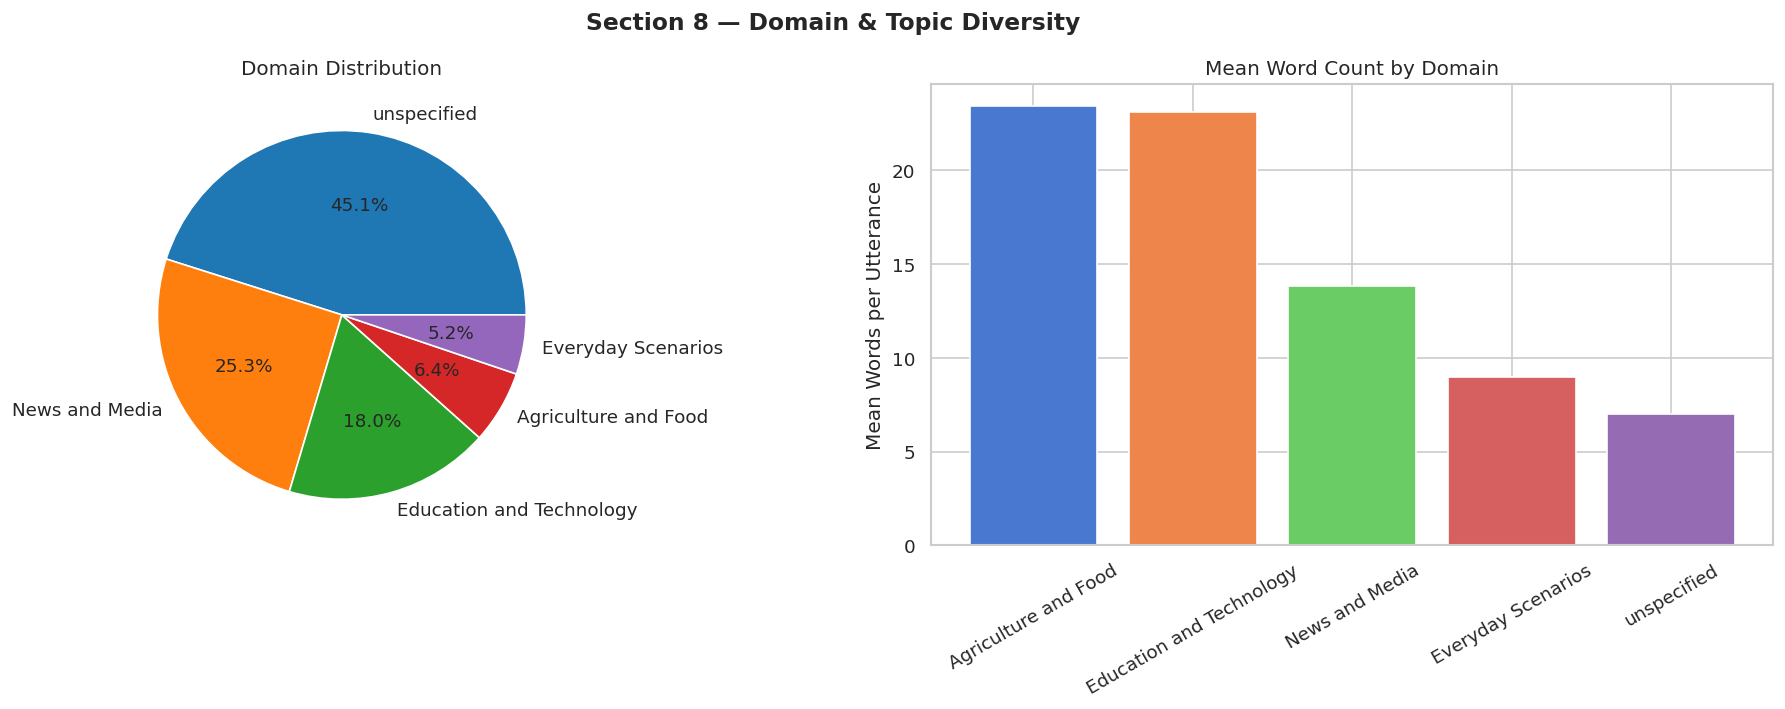

✅ Saved: eda_section8_domain_diversity.png


In [28]:
print("\n" + "="*60)
print("SECTION 8: DOMAIN & TOPIC DIVERSITY")
print("="*60)

# If no domain column, infer domain from keywords in transcripts
domain_keywords = {
    "Sports":      ["mūbira", "timu", "ngoru", "mūbira", "mūthako", "mūtambūrūko", "magūrū"],
    "Nature":      ["mūtī", "nyeki", "mūtitu", "njogu", "nyamū", "rūì", "ūgūrū", "ndīrītū"],
    "Food":        ["irio", "nyama", "mūceere", "ngūkū", "mūkimo", "gìtheri", "matoke"],
    "Health":      ["ndwari", "mūrimū", "daktari", "ithaburū", "ūgima", "thigari"],
    "Geography":   ["Kenya", "Africa", "Tanzania", "Uganda", "Nairobi", "mūtū", "rūì"],
    "Politics":    ["gавети", "president", "ūtongoria", "watho", "kìama", "bunge"],
    "Religion":    ["Ngai", "Jesu", "kanitha", "thayū", "gūtīra", "mwathani"],
    "Education":   ["cukuru", "mūīgīzwa", "mwarimu", "buku", "gūīga", "ūhoro"],
    "Family":      ["mūciī", "nyina", "baba", "ciana", "mūhiki", "mūndūrume"],
    "Economics":   ["thogora", "wìra", "kùria", "mùcì", "economì", "magoti"],
}

def infer_domain(text):
    text_lower = text.lower()
    for domain, keywords in domain_keywords.items():
        if any(kw.lower() in text_lower for kw in keywords):
            return domain
    return "Other"

if "domain" in df.columns:
    df["inferred_domain"] = df["domain"]
    print("  Using dataset's own domain column.")
else:
    df["inferred_domain"] = df["transcript"].apply(infer_domain)
    print("  No domain column found — domains inferred from keywords.")

domain_counts = df["inferred_domain"].value_counts()
print(f"\n  Domain distribution:")
print(domain_counts.to_string())

# Most common words per domain
print("\n  Top 5 words per domain:")
for domain in domain_counts.index[:5]:
    domain_text = " ".join(df[df["inferred_domain"] == domain]["transcript"].tolist()).lower()
    domain_words = Counter(w for w in domain_text.split() if len(w) > 3)
    top5 = [w for w, _ in domain_words.most_common(5)]
    print(f"    {domain}: {top5}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Section 8 — Domain & Topic Diversity",
             fontsize=14, fontweight="bold")

# Domain pie
axes[0].pie(domain_counts.values, labels=domain_counts.index,
            autopct="%1.1f%%", colors=sns.color_palette("tab10", len(domain_counts)))
axes[0].set_title("Domain Distribution")

# Domain bar + mean word count
domain_wc = df.groupby("inferred_domain")["word_count"].mean().sort_values(ascending=False)
axes[1].bar(domain_wc.index, domain_wc.values,
            color=sns.color_palette("muted", len(domain_wc)))
axes[1].set_title("Mean Word Count by Domain")
axes[1].set_ylabel("Mean Words per Utterance")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("eda_section8_domain_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section8_domain_diversity.png")



SECTION 9: DATA PROVENANCE & LICENSING
  Dataset name:     Anv-ke/kikuyu
  Author/Org:       Anv-ke
  Could not fetch dataset info: 'DatasetInfo' object has no attribute 'license'
  Please check the dataset page manually at:
  https://huggingface.co/datasets/Anv-ke/kikuyu

  Checking for source indicators in transcriptions...
  Possible Wikipedia source: 0 utterances
  Possible News source:      4 utterances
  Possible Religious source: 8 utterances


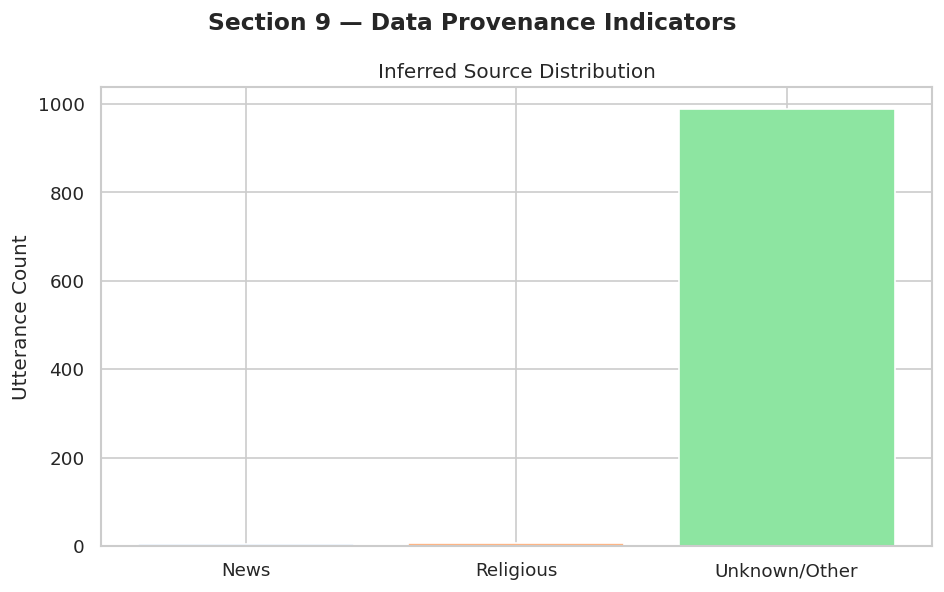

✅ Saved: eda_section9_provenance.png


In [29]:
print("\n" + "="*60)
print("SECTION 9: DATA PROVENANCE & LICENSING")
print("="*60)

# Try to fetch dataset card info from HuggingFace
try:
    from huggingface_hub import dataset_info, DatasetCard
    info = dataset_info(DATASET_NAME)
    print(f"  Dataset name:     {info.id}")
    print(f"  Author/Org:       {info.author}")
    print(f"  License:          {info.license if info.license else 'Not specified'}")
    print(f"  Last modified:    {info.last_modified}")
    print(f"  Downloads (30d):  {info.downloads}")
    print(f"  Tags:             {info.tags}")

    try:
        card = DatasetCard.load(DATASET_NAME)
        card_text = card.content[:2000]
        print(f"\n  Dataset Card Preview (first 2000 chars):")
        print(f"  {'-'*50}")
        print(card_text)
    except Exception:
        print("  (Dataset card not available)")

except Exception as e:
    print(f"  Could not fetch dataset info: {e}")
    print("  Please check the dataset page manually at:")
    print(f"  https://huggingface.co/datasets/{DATASET_NAME}")

# Source prefix analysis from transcripts
print("\n  Checking for source indicators in transcriptions...")
has_wikipedia = df["transcript"].str.contains("wikipedia", case=False, na=False).sum()
has_news      = df["transcript"].str.contains("news|habari|gazeti", case=False, na=False).sum()
has_bible     = df["transcript"].str.contains("Ngai|Jesu|Bible|thayū", case=False, na=False).sum()

print(f"  Possible Wikipedia source: {has_wikipedia} utterances")
print(f"  Possible News source:      {has_news} utterances")
print(f"  Possible Religious source: {has_bible} utterances")

# Visualise provenance indicators
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Section 9 — Data Provenance Indicators",
             fontsize=14, fontweight="bold")
sources = {"Wikipedia": has_wikipedia, "News": has_news,
           "Religious": has_bible,
           "Unknown/Other": len(df) - has_wikipedia - has_news - has_bible}
sources = {k: v for k, v in sources.items() if v > 0}
ax.bar(sources.keys(), sources.values(),
       color=sns.color_palette("pastel", len(sources)))
ax.set_title("Inferred Source Distribution")
ax.set_ylabel("Utterance Count")
plt.tight_layout()
plt.savefig("eda_section9_provenance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section9_provenance.png")



SECTION 10: NOISE & ANOMALY DETECTION
  Clean samples:            987 (98.7%)
  Samples with anomalies:   13 (1.3%)

  Anomaly breakdown:
      13 — excessive_silence


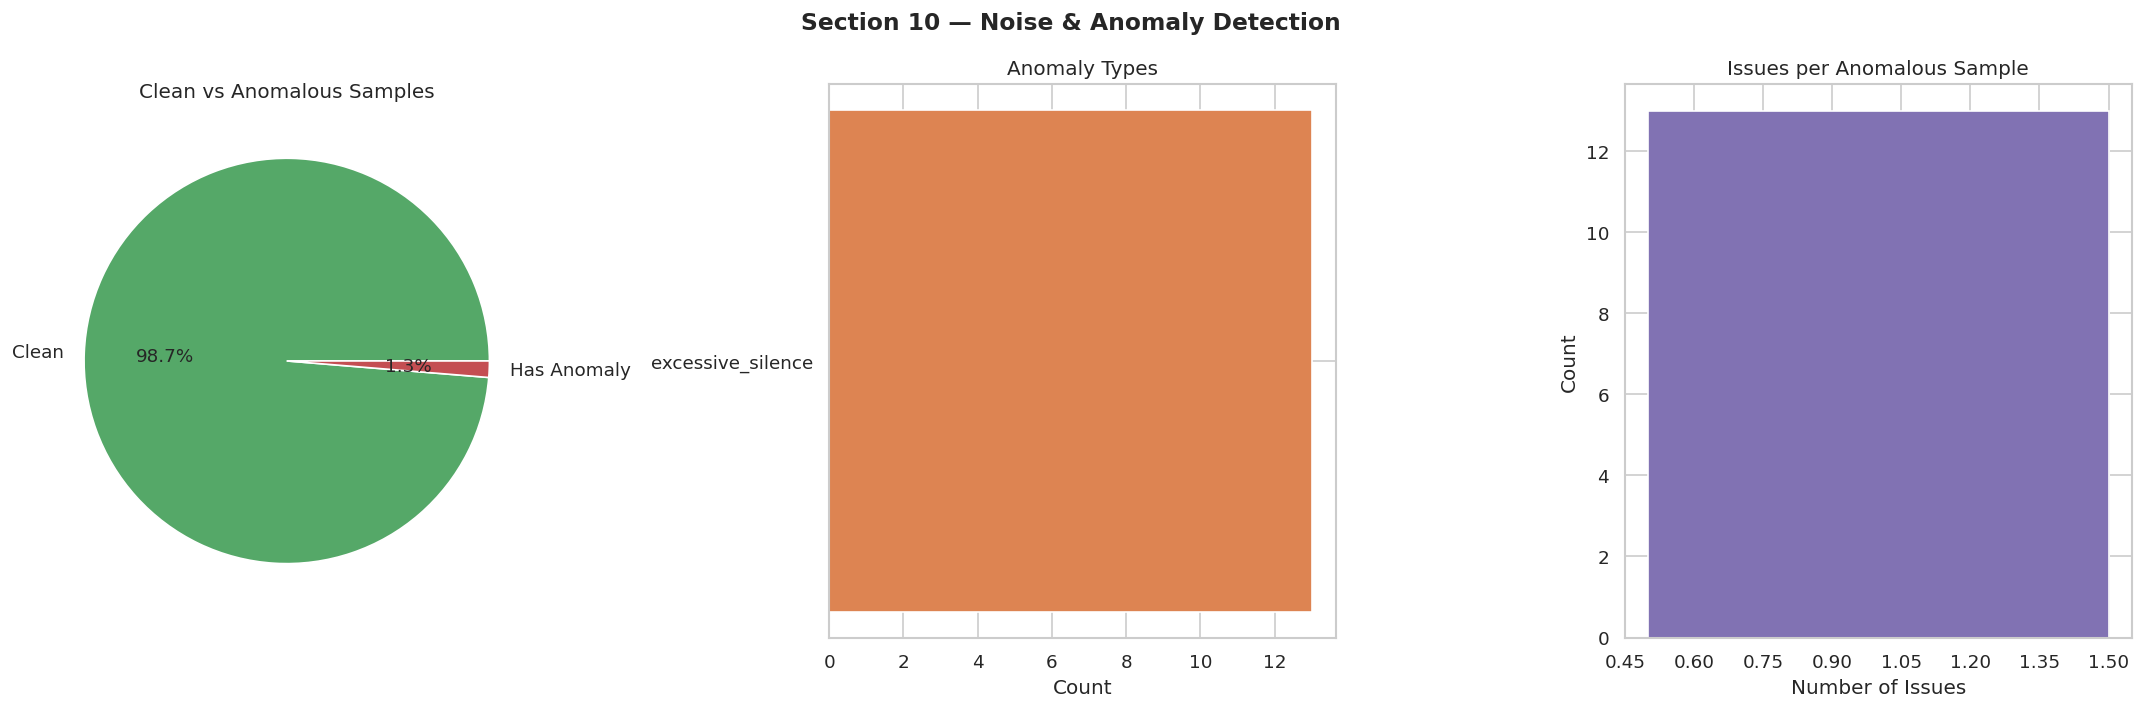

✅ Saved: eda_section10_anomalies.png


In [30]:
print("\n" + "="*60)
print("SECTION 10: NOISE & ANOMALY DETECTION")
print("="*60)

anomalies = []

for idx, row in df.iterrows():
    issues = []

    # Audio anomalies
    if row["is_clipped"]:
        issues.append("clipped_audio")
    if row["silence_ratio"] > 0.6:
        issues.append("excessive_silence")
    if row["duration_sec"] < 0.5:
        issues.append("too_short_audio")
    if row["duration_sec"] > 60:
        issues.append("too_long_audio")
    if row["rms"] < 0.001:
        issues.append("near_silent")

    # Text anomalies
    if row["has_url"]:
        issues.append("url_in_transcript")
    if row["has_newline"]:
        issues.append("newlines_in_transcript")
    if row["has_underscore"]:
        issues.append("underscores_in_transcript")
    if row["word_count"] < 2:
        issues.append("too_short_transcript")
    if row["word_count"] > 250:
        issues.append("too_long_transcript")

    # Alignment anomalies
    wps = row.get("wps", row["word_count"] / max(row["duration_sec"], 0.001))
    if wps > 6:
        issues.append("alignment_too_fast")
    if wps < 0.3:
        issues.append("alignment_too_slow")

    if issues:
        anomalies.append({
            "index":     idx,
            "issues":    "; ".join(issues),
            "n_issues":  len(issues),
            "transcript": row["transcript"][:80] + "..." if len(row["transcript"]) > 80 else row["transcript"],
        })

df_anomalies = pd.DataFrame(anomalies)
clean_count  = len(df) - len(df_anomalies)

print(f"  Clean samples:            {clean_count} ({clean_count/len(df)*100:.1f}%)")
print(f"  Samples with anomalies:   {len(df_anomalies)} ({len(df_anomalies)/len(df)*100:.1f}%)")

if len(df_anomalies) > 0:
    all_issues = []
    for issues_str in df_anomalies["issues"]:
        all_issues.extend(issues_str.split("; "))
    issue_counts = Counter(all_issues)
    print(f"\n  Anomaly breakdown:")
    for issue, count in sorted(issue_counts.items(), key=lambda x: -x[1]):
        print(f"    {count:>4} — {issue}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section 10 — Noise & Anomaly Detection",
             fontsize=14, fontweight="bold")

# Clean vs anomalous pie
axes[0].pie([clean_count, len(df_anomalies)],
            labels=["Clean", "Has Anomaly"],
            autopct="%1.1f%%",
            colors=["#55A868", "#C44E52"])
axes[0].set_title("Clean vs Anomalous Samples")

# Issue type bar chart
if len(df_anomalies) > 0:
    issues_df = pd.DataFrame(issue_counts.most_common(),
                             columns=["Issue", "Count"])
    axes[1].barh(issues_df["Issue"], issues_df["Count"], color="#DD8452")
    axes[1].set_title("Anomaly Types")
    axes[1].set_xlabel("Count")
    axes[1].invert_yaxis()

# Number of issues per anomalous sample
if len(df_anomalies) > 0:
    axes[2].hist(df_anomalies["n_issues"], bins=range(1, df_anomalies["n_issues"].max() + 2),
                 color="#8172B3", edgecolor="white", align="left")
    axes[2].set_title("Issues per Anomalous Sample")
    axes[2].set_xlabel("Number of Issues")
    axes[2].set_ylabel("Count")
    axes[2].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("eda_section10_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_section10_anomalies.png")

In [31]:
print("\n" + "="*60)
print("FULL EDA SUMMARY REPORT")
print("="*60)

print(f"""
DATASET:          {DATASET_NAME}
SAMPLES ANALYSED: {len(df):,}

── DATA VOLUME ──────────────────────────────────────────────
  Total audio:    {df['duration_sec'].sum()/3600:.2f} hours in sample
  Mean duration:  {df['duration_sec'].mean():.2f} seconds
  Mean words:     {df['word_count'].mean():.1f} per utterance

── AUDIO QUALITY ────────────────────────────────────────────
  Clipped:        {df['is_clipped'].sum()} ({df['is_clipped'].mean()*100:.1f}%)
  High silence:   {(df['silence_ratio'] > 0.5).sum()} files
  Very short:     {(df['duration_sec'] < 1).sum()} files

── TRANSCRIPT QUALITY ───────────────────────────────────────
  Has URLs:       {df['has_url'].sum()} ({df['has_url'].mean()*100:.1f}%)
  Has newlines:   {df['has_newline'].sum()} ({df['has_newline'].mean()*100:.1f}%)
  Has underscore: {df['has_underscore'].sum()} ({df['has_underscore'].mean()*100:.1f}%)

── ALIGNMENT ────────────────────────────────────────────────
  Normal WPS:     {((df['wps']>=0.5)&(df['wps']<=5)).sum()} ({((df['wps']>=0.5)&(df['wps']<=5)).mean()*100:.1f}%)
  Too fast:       {(df['wps']>5).sum()} utterances
  Too slow:       {(df['wps']<0.5).sum()} utterances

── ANOMALIES ────────────────────────────────────────────────
  Clean samples:  {clean_count} ({clean_count/len(df)*100:.1f}%)
  With issues:    {len(df_anomalies)} ({len(df_anomalies)/len(df)*100:.1f}%)

── GRAPHEMES ────────────────────────────────────────────────
  Unique chars:   {len(graphemes)}

── SAVED PLOTS ──────────────────────────────────────────────
  eda_section1_volume.png
  eda_section2_audio_quality.png
  eda_section3_transcript_quality.png
  eda_section4_speaker_diversity.png
  eda_section5_utterance_stats.png
  eda_section6_alignment.png
  eda_section7_grapheme_coverage.png
  eda_section8_domain_diversity.png
  eda_section9_provenance.png
  eda_section10_anomalies.png
""")


FULL EDA SUMMARY REPORT

DATASET:          Anv-ke/kikuyu
SAMPLES ANALYSED: 1,000
 
── DATA VOLUME ──────────────────────────────────────────────
  Total audio:    1.81 hours in sample
  Mean duration:  6.50 seconds
  Mean words:     12.8 per utterance
 
── AUDIO QUALITY ────────────────────────────────────────────
  Clipped:        0 (0.0%)
  High silence:   28 files
  Very short:     1 files
 
── TRANSCRIPT QUALITY ───────────────────────────────────────
  Has URLs:       0 (0.0%)
  Has newlines:   0 (0.0%)
  Has underscore: 0 (0.0%)
 
── ALIGNMENT ────────────────────────────────────────────────
  Normal WPS:     1000 (100.0%)
  Too fast:       0 utterances
  Too slow:       0 utterances
 
── ANOMALIES ────────────────────────────────────────────────
  Clean samples:  987 (98.7%)
  With issues:    13 (1.3%)
 
── GRAPHEMES ────────────────────────────────────────────────
  Unique chars:   45
 
── SAVED PLOTS ──────────────────────────────────────────────
  eda_section1_volume.png
  e

In [32]:
import numpy as np
import pandas as pd
from pathlib import Path
import textwrap

# Helper to print section headers
def header(title):
    print("\n" + "=" * 65)
    print(f"  {title}")
    print("=" * 65)

def bullet(symbol, text, indent=4):
    prefix = " " * indent + symbol + " "
    wrapped = textwrap.fill(text, width=65,
                            subsequent_indent=" " * (len(prefix)))
    print(prefix + wrapped[len(prefix) - len(symbol) - indent - 1:]
          if len(prefix) <= len(wrapped) else prefix + text)

def print_bullet(symbol, text):
    lines = textwrap.wrap(text, width=58)
    print(f"    {symbol} {lines[0]}")
    for line in lines[1:]:
        print(f"       {line}")

In [33]:
header("BUILDING STATS FROM EDA DATA")

stats = {}

# Volume
stats["volume"] = {
    "total_samples":       int(len(df)),
    "total_audio_hours":   round(float(df["duration_sec"].sum() / 3600), 3),
    "mean_duration_sec":   round(float(df["duration_sec"].mean()), 2),
    "median_duration_sec": round(float(df["duration_sec"].median()), 2),
    "min_duration_sec":    round(float(df["duration_sec"].min()), 2),
    "max_duration_sec":    round(float(df["duration_sec"].max()), 2),
    "mean_words":          round(float(df["word_count"].mean()), 2),
    "total_words":         int(df["word_count"].sum()),
}

# Audio quality
stats["audio"] = {
    "clipped_pct":       round(float(df["is_clipped"].mean() * 100), 2),
    "high_silence_pct":  round(float((df["silence_ratio"] > 0.5).mean() * 100), 2),
    "very_short_pct":    round(float((df["duration_sec"] < 1).mean() * 100), 2),
    "very_long_pct":     round(float((df["duration_sec"] > 30).mean() * 100), 2),
    "near_silent_pct":   round(float((df["rms"] < 0.001).mean() * 100), 2),
    "mean_rms":          round(float(df["rms"].mean()), 5),
    "mean_silence_ratio":round(float(df["silence_ratio"].mean()), 3),
}

# Transcript quality
stats["transcript"] = {
    "has_url_pct":        round(float(df["has_url"].mean() * 100), 2),
    "has_newline_pct":    round(float(df["has_newline"].mean() * 100), 2),
    "has_underscore_pct": round(float(df["has_underscore"].mean() * 100), 2),
    "empty_pct":          round(float((df["word_count"] == 0).mean() * 100), 2),
    "unique_graphemes":   int(len(graphemes)),
    "mean_words":         round(float(df["word_count"].mean()), 2),
}

# Diacritic inconsistency
all_text = " ".join(df["transcript"].tolist()).lower()
i_variants = {c: all_text.count(c) for c in ["i","ì","ĩ","í","î","ī","ï"] if all_text.count(c) > 0}
u_variants = {c: all_text.count(c) for c in ["u","ū","ù","ũ","ú","û","ü"] if all_text.count(c) > 0}
stats["diacritics"] = {
    "i_variant_count": len(i_variants),
    "u_variant_count": len(u_variants),
    "i_variants":      i_variants,
    "u_variants":      u_variants,
}

# Speaker diversity
if "speaker_id" in df.columns:
    sc = df["speaker_id"].value_counts()
    stats["speakers"] = {
        "unique_speakers":       int(df["speaker_id"].nunique()),
        "mean_utts_per_speaker": round(float(sc.mean()), 2),
        "max_utts_per_speaker":  int(sc.max()),
        "min_utts_per_speaker":  int(sc.min()),
        "top_speaker_pct":       round(float(sc.iloc[0] / len(df) * 100), 2),
        "speakers_lt5_utts":     int((sc < 5).sum()),
    }
else:
    stats["speakers"] = None

# Alignment
df["wps"] = df["word_count"] / df["duration_sec"].replace(0, np.nan)
stats["alignment"] = {
    "mean_wps":         round(float(df["wps"].mean()), 3),
    "normal_pct":       round(float(((df["wps"] >= 0.5) & (df["wps"] <= 5)).mean() * 100), 2),
    "too_fast_pct":     round(float((df["wps"] > 5).mean() * 100), 2),
    "too_slow_pct":     round(float((df["wps"] < 0.5).mean() * 100), 2),
}

# Anomalies
if "df_anomalies" in dir() and "clean_count" in dir():
    stats["anomalies"] = {
        "clean_pct":     round(float(clean_count / len(df) * 100), 2),
        "anomaly_pct":   round(float(len(df_anomalies) / len(df) * 100), 2),
        "total_anomalous": int(len(df_anomalies)),
    }
else:
    stats["anomalies"] = {"clean_pct": None, "anomaly_pct": None}

# Domain
if "inferred_domain" in df.columns:
    dc = df["inferred_domain"].value_counts()
    stats["domain"] = {
        "unique_domains":      int(df["inferred_domain"].nunique()),
        "dominant_domain":     str(dc.index[0]),
        "dominant_domain_pct": round(float(dc.iloc[0] / len(df) * 100), 2),
    }
else:
    stats["domain"] = None

print("✅ Stats built successfully")



  BUILDING STATS FROM EDA DATA
✅ Stats built successfully


In [34]:
def score_volume(s):
    issues, positives, actions = [], [], []
    hours = s["total_audio_hours"]
    samples = s["total_samples"]

    # Scoring
    if hours >= 100:
        score = 5; positives.append(f"Excellent volume: {hours:.1f} hours is well above the 10-hour minimum for ASR fine-tuning.")
    elif hours >= 50:
        score = 4; positives.append(f"Good volume: {hours:.1f} hours is sufficient for fine-tuning.")
    elif hours >= 10:
        score = 3; issues.append(f"Moderate volume: {hours:.1f} hours. More data would improve generalisation.")
        actions.append("Collect more audio — aim for at least 50 hours for reliable Kikuyu ASR.")
    elif hours >= 2:
        score = 2; issues.append(f"Low volume: only {hours:.1f} hours. Model will likely underfit.")
        actions.append("Prioritise data collection. Use data augmentation (speed, pitch, noise) to artificially expand the dataset.")
    else:
        score = 1; issues.append(f"Critical: only {hours:.1f} hours. Not enough to train a usable model.")
        actions.append("Do not train until you have at least 5 hours of clean audio.")

    if s["mean_duration_sec"] < 2:
        issues.append(f"Very short mean utterance ({s['mean_duration_sec']:.1f}s) — utterances may be too fragmented.")
        actions.append("Consider merging consecutive short utterances from the same speaker into longer ones.")
    elif 3 <= s["mean_duration_sec"] <= 15:
        positives.append(f"Healthy mean utterance length: {s['mean_duration_sec']:.1f}s — ideal for Whisper.")

    if s["max_duration_sec"] > 30:
        issues.append(f"Some utterances exceed 30s (max={s['max_duration_sec']:.1f}s). Whisper only processes 30s windows.")
        actions.append("Split all utterances longer than 30 seconds into shorter segments.")

    return score, issues, positives, actions


def score_audio(s):
    issues, positives, actions = [], [], []
    score = 5

    if s["clipped_pct"] > 10:
        score = min(score, 2)
        issues.append(f"High clipping rate: {s['clipped_pct']:.1f}% of audio is clipped (peak ≥ 0.99). Clipping distorts the signal permanently.")
        actions.append("Re-record clipped files if possible. If not, apply a soft-clip limiter and flag these files as lower quality.")
    elif s["clipped_pct"] > 3:
        score = min(score, 3)
        issues.append(f"Moderate clipping: {s['clipped_pct']:.1f}% of files.")
        actions.append("Review recording equipment gain settings. Apply normalisation to clipped files.")
    else:
        positives.append(f"Low clipping rate: {s['clipped_pct']:.1f}% — recording levels are well controlled.")

    if s["high_silence_pct"] > 20:
        score = min(score, 2)
        issues.append(f"High silence: {s['high_silence_pct']:.1f}% of files have >50% silence. Model wastes compute on silent frames.")
        actions.append("Apply Voice Activity Detection (VAD) using silero-vad or webrtcvad to trim leading/trailing silence.")
    elif s["high_silence_pct"] > 5:
        score = min(score, 3)
        issues.append(f"Some files have excessive silence ({s['high_silence_pct']:.1f}%).")
        actions.append("Run VAD trimming on the full dataset before training.")
    else:
        positives.append(f"Good silence ratio: only {s['high_silence_pct']:.1f}% of files have excessive silence.")

    if s["near_silent_pct"] > 2:
        score = min(score, 2)
        issues.append(f"{s['near_silent_pct']:.1f}% of files are near-silent (RMS < 0.001). These are likely corrupted or empty.")
        actions.append("Remove near-silent files from the dataset entirely.")

    if s["very_short_pct"] > 5:
        score = min(score, 3)
        issues.append(f"{s['very_short_pct']:.1f}% of audio files are under 1 second — too short to transcribe.")
        actions.append("Filter out all audio files shorter than 1 second.")

    if s["mean_rms"] > 0.01:
        positives.append(f"Good average loudness (RMS={s['mean_rms']:.4f}) — audio is clearly recorded.")

    return score, issues, positives, actions


def score_transcript(s, d):
    issues, positives, actions = [], [], []
    score = 5

    if s["has_url_pct"] > 5:
        score = min(score, 2)
        issues.append(f"{s['has_url_pct']:.1f}% of transcriptions contain URLs — these are never spoken in audio.")
        actions.append("Strip all URLs from transcriptions using: re.sub(r'https?://\\S+', '', text)")
    elif s["has_url_pct"] > 0:
        score = min(score, 4)
        issues.append(f"{s['has_url_pct']:.1f}% of transcriptions have URLs.")
        actions.append("Clean URLs from transcriptions before training.")

    if s["has_newline_pct"] > 10:
        score = min(score, 3)
        issues.append(f"{s['has_newline_pct']:.1f}% of transcriptions contain newline characters.")
        actions.append("Replace all newlines with a space: text.replace('\\n', ' ')")

    if s["has_underscore_pct"] > 5:
        score = min(score, 3)
        issues.append(f"{s['has_underscore_pct']:.1f}% of transcriptions use underscores as word joiners.")
        actions.append("Replace underscores with spaces: text.replace('_', ' ')")

    if s["empty_pct"] > 0:
        score = min(score, 3)
        issues.append(f"{s['empty_pct']:.1f}% of transcriptions are empty.")
        actions.append("Remove all rows with empty transcriptions.")

    # Diacritic inconsistency
    n_i = d["i_variant_count"]
    n_u = d["u_variant_count"]
    if n_i > 3 or n_u > 3:
        score = min(score, 2)
        issues.append(f"Severe diacritic inconsistency: {n_i} variants of 'i' and {n_u} variants of 'u' found. The same spoken word is spelled multiple ways.")
        actions.append("Standardise diacritics — pick one form for each vowel and apply globally. Use the diacritic_map from clean_dataset.py.")
    elif n_i > 1 or n_u > 1:
        score = min(score, 3)
        issues.append(f"Some diacritic variation: {n_i} 'i' variants, {n_u} 'u' variants.")
        actions.append("Normalise diacritics across the dataset for consistency.")
    else:
        positives.append("Diacritic usage is consistent — same vowel always spelled the same way.")

    if s["unique_graphemes"] >= 30:
        positives.append(f"Rich grapheme inventory: {s['unique_graphemes']} unique characters — good coverage of Kikuyu sounds.")

    return score, issues, positives, actions


def score_speakers(s):
    issues, positives, actions = [], [], []

    if s is None:
        return 3, ["No speaker_id column — cannot assess speaker diversity."], [], \
               ["Add speaker metadata to the dataset if possible for better diversity analysis."]

    score = 5
    n = s["unique_speakers"]

    if n < 10:
        score = 1
        issues.append(f"Only {n} unique speakers — model will overfit to these specific voices.")
        actions.append("Collect audio from at least 50 diverse speakers (different ages, genders, dialects).")
    elif n < 30:
        score = 2
        issues.append(f"Low speaker diversity: {n} speakers. Risky for generalisation.")
        actions.append("Aim for 50+ speakers. Prioritise speakers that are underrepresented.")
    elif n < 100:
        score = 3
        positives.append(f"Moderate diversity: {n} speakers.")
        actions.append("Continue adding more speakers, especially from different Kikuyu dialect regions.")
    else:
        score = 5
        positives.append(f"Excellent speaker diversity: {n} unique speakers.")

    if s["top_speaker_pct"] > 30:
        score = min(score, 2)
        issues.append(f"One speaker dominates: {s['top_speaker_pct']:.1f}% of all data. Model will be biased to that voice.")
        actions.append("Cap each speaker at a maximum of 10% of the total dataset. Remove excess utterances from dominant speakers.")

    if s["speakers_lt5_utts"] > s["unique_speakers"] * 0.3:
        issues.append(f"Many speakers have very few utterances (<5). These contribute little to learning.")
        actions.append("Either collect more utterances from sparse speakers or remove them from training.")

    if s["mean_utts_per_speaker"] >= 20:
        positives.append(f"Good utterance coverage per speaker: mean of {s['mean_utts_per_speaker']:.0f} utterances.")

    return score, issues, positives, actions


def score_alignment(s):
    issues, positives, actions = [], [], []
    score = 5

    if s["normal_pct"] < 70:
        score = 1
        issues.append(f"Critical alignment problem: only {s['normal_pct']:.1f}% of utterances have normal words-per-second (0.5–5 wps).")
        actions.append("Manually review a sample of misaligned utterances. Consider re-aligning using a forced aligner like Montreal Forced Aligner (MFA).")
    elif s["normal_pct"] < 85:
        score = 2
        issues.append(f"Significant alignment issues: {s['normal_pct']:.1f}% normal alignment.")
        actions.append("Filter out utterances with WPS < 0.3 or WPS > 7 as likely mismatched pairs.")
    elif s["normal_pct"] < 95:
        score = 3
        issues.append(f"Minor alignment issues: {s['normal_pct']:.1f}% normal alignment.")
        actions.append("Filter extreme outliers (WPS < 0.3 or WPS > 7) before training.")
    else:
        score = 5
        positives.append(f"Excellent alignment: {s['normal_pct']:.1f}% of utterances have healthy words-per-second ratios.")

    if s["too_fast_pct"] > 5:
        issues.append(f"{s['too_fast_pct']:.1f}% of utterances are suspiciously fast (>5 wps). These likely have the wrong transcription.")
        actions.append("Inspect fast-WPS utterances — many will be transcription-audio mismatches. Remove or re-transcribe.")

    if s["too_slow_pct"] > 5:
        issues.append(f"{s['too_slow_pct']:.1f}% of utterances are suspiciously slow (<0.5 wps). These likely have excessive silence or very sparse transcriptions.")
        actions.append("Apply VAD trimming to slow-WPS utterances and re-check alignment.")

    return score, issues, positives, actions


def score_anomalies(s):
    issues, positives, actions = [], [], []

    if s["clean_pct"] is None:
        return 3, ["Anomaly stats not available."], [], []

    score = 5
    clean = s["clean_pct"]
    anomaly = s["anomaly_pct"]

    if clean >= 90:
        score = 5
        positives.append(f"Very clean dataset: {clean:.1f}% of samples are anomaly-free.")
    elif clean >= 75:
        score = 4
        positives.append(f"Mostly clean: {clean:.1f}% anomaly-free.")
        issues.append(f"{anomaly:.1f}% of samples have at least one issue.")
        actions.append("Run clean_dataset.py to fix the flagged issues before training.")
    elif clean >= 50:
        score = 2
        issues.append(f"Only {clean:.1f}% of samples are fully clean — significant noise in the dataset.")
        actions.append("Run clean_dataset.py. Review the removed_audios_report.csv and salvage fixable rows.")
    else:
        score = 1
        issues.append(f"Critical: only {clean:.1f}% of samples are clean. Training on this data will produce a poor model.")
        actions.append("Do not train until the dataset has been thoroughly cleaned. Focus cleaning effort on URL removal, diacritic normalisation, and alignment filtering.")

    return score, issues, positives, actions

In [35]:
header("SECTION-BY-SECTION INTERPRETATION")

section_results = {}

sections = [
    ("Data Volume & Coverage",              score_volume,    stats["volume"]),
    ("Audio Quality",                       score_audio,     stats["audio"]),
    ("Transcript Quality & Linguistics",    score_transcript,stats["transcript"]),
    ("Speaker Diversity",                   score_speakers,  stats["speakers"]),
    ("Text-Audio Alignment Integrity",      score_alignment, stats["alignment"]),
    ("Noise & Anomaly Detection",           score_anomalies, stats["anomalies"]),
]

# Transcript scorer needs both transcript + diacritic stats
for name, scorer, stat in sections:
    if name == "Transcript Quality & Linguistics":
        score, issues, positives, actions = scorer(stat, stats["diacritics"])
    else:
        score, issues, positives, actions = scorer(stat)

    section_results[name] = {
        "score": score, "issues": issues,
        "positives": positives, "actions": actions
    }

    stars = "★" * score + "☆" * (5 - score)
    print(f"\n── {name}  [{stars}  {score}/5] ──")

    if positives:
        print("  ✅ What is good:")
        for p in positives:
            print_bullet("•", p)

    if issues:
        print("  ⚠️  Concerns:")
        for issue in issues:
            print_bullet("•", issue)

    if actions:
        print("  🔧 Actions:")
        for i, a in enumerate(actions, 1):
            print_bullet(f"{i}.", a)


  SECTION-BY-SECTION INTERPRETATION

── Data Volume & Coverage  [★☆☆☆☆  1/5] ──
  ✅ What is good:
    • Healthy mean utterance length: 6.5s — ideal for Whisper.
  ⚠️  Concerns:
    • Critical: only 1.8 hours. Not enough to train a usable
       model.
    • Some utterances exceed 30s (max=34.7s). Whisper only
       processes 30s windows.
  🔧 Actions:
    1. Do not train until you have at least 5 hours of clean
       audio.
    2. Split all utterances longer than 30 seconds into shorter
       segments.

── Audio Quality  [★★★★★  5/5] ──
  ✅ What is good:
    • Low clipping rate: 0.0% — recording levels are well
       controlled.
    • Good silence ratio: only 2.8% of files have excessive
       silence.
    • Good average loudness (RMS=0.0708) — audio is clearly
       recorded.

── Transcript Quality & Linguistics  [★★☆☆☆  2/5] ──
  ✅ What is good:
    • Rich grapheme inventory: 45 unique characters — good
       coverage of Kikuyu sounds.
  ⚠️  Concerns:
    • Severe diacritic in